**Objective:** Develop a machine learning model to predict whether a customer is likely to exit the bank, enabling proactive customer retention and reducing churn.

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder,OrdinalEncoder,LabelEncoder,MinMaxScaler, PowerTransformer
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split,KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report,roc_curve,roc_auc_score,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier 
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Load the dataset and understand the data

In [120]:
df=pd.read_excel('Churn.xlsx')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [121]:
#Checking datatypes
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [122]:
#Checking null values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [123]:
#Checking Duplicate values
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


## Descriptive Statistics

In [124]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [125]:
df.describe(include=object).T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


## Data Exploration (EDA)

### Univariate Analysis

In [126]:
num_cols = ['CreditScore','Age', 'Balance','EstimatedSalary']
cat_cols = ['Geography','Gender','NumOfProducts', 'HasCrCard',
       'IsActiveMember','Exited','Tenure']

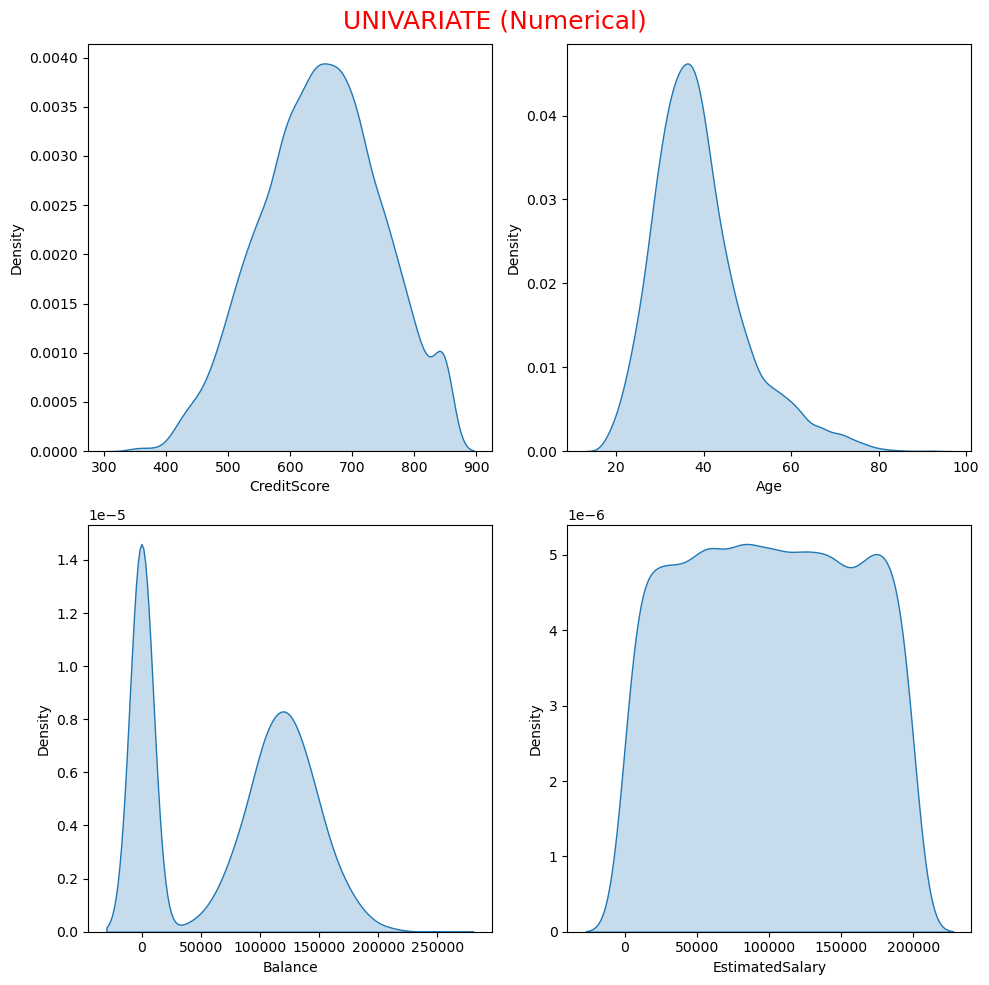

In [127]:
t=1
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num_cols:
    plt.rcParams['figure.figsize']=[10,10]
    plt.subplot(2,2,t)
    sns.kdeplot(df[i], fill=True)
    t+=1
plt.tight_layout()
plt.show()

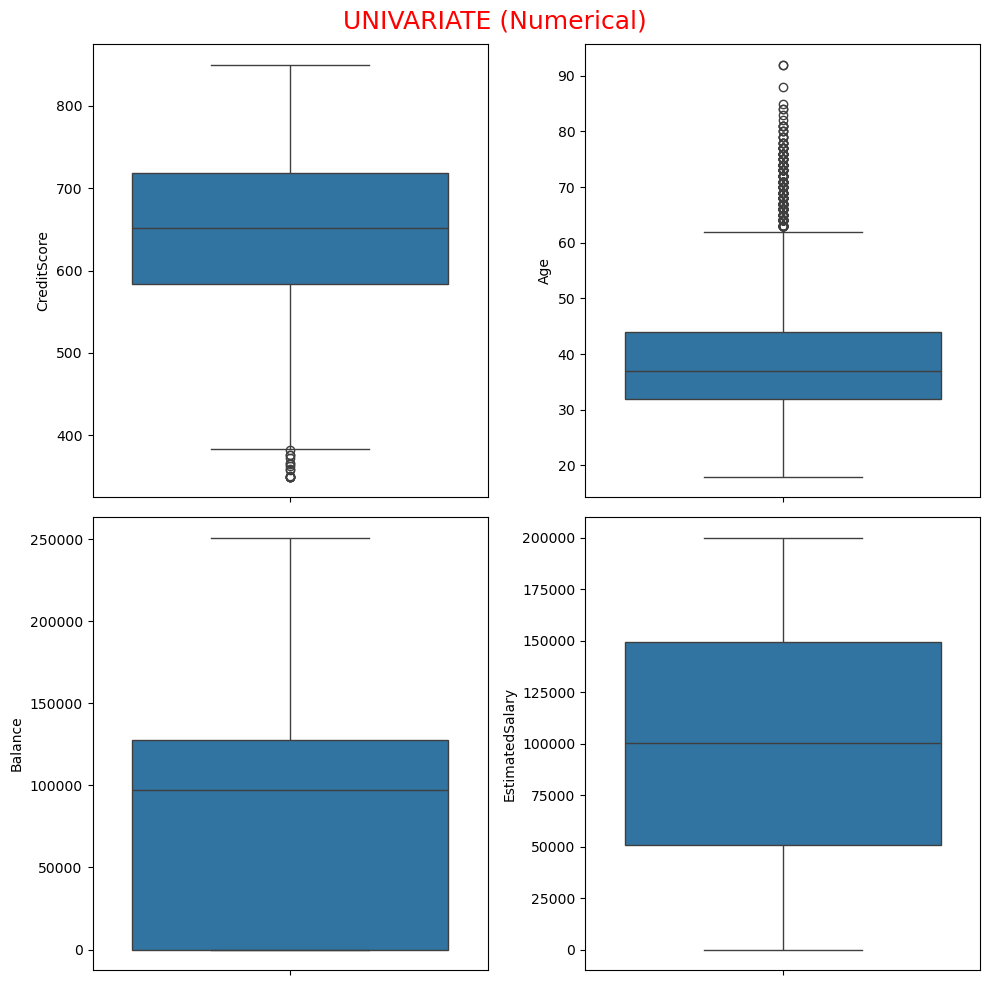

In [128]:
t=1
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num_cols:
    plt.rcParams['figure.figsize']=[10,10]
    plt.subplot(2,2,t)
    sns.boxplot(df[i])
    t+=1
plt.tight_layout()
plt.show()

In [118]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [130]:
#pd.crosstab(df['Geography'], df['Exited'])
pd.crosstab(df['Geography'],df['Exited']) #geography has no such relationship with churn

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


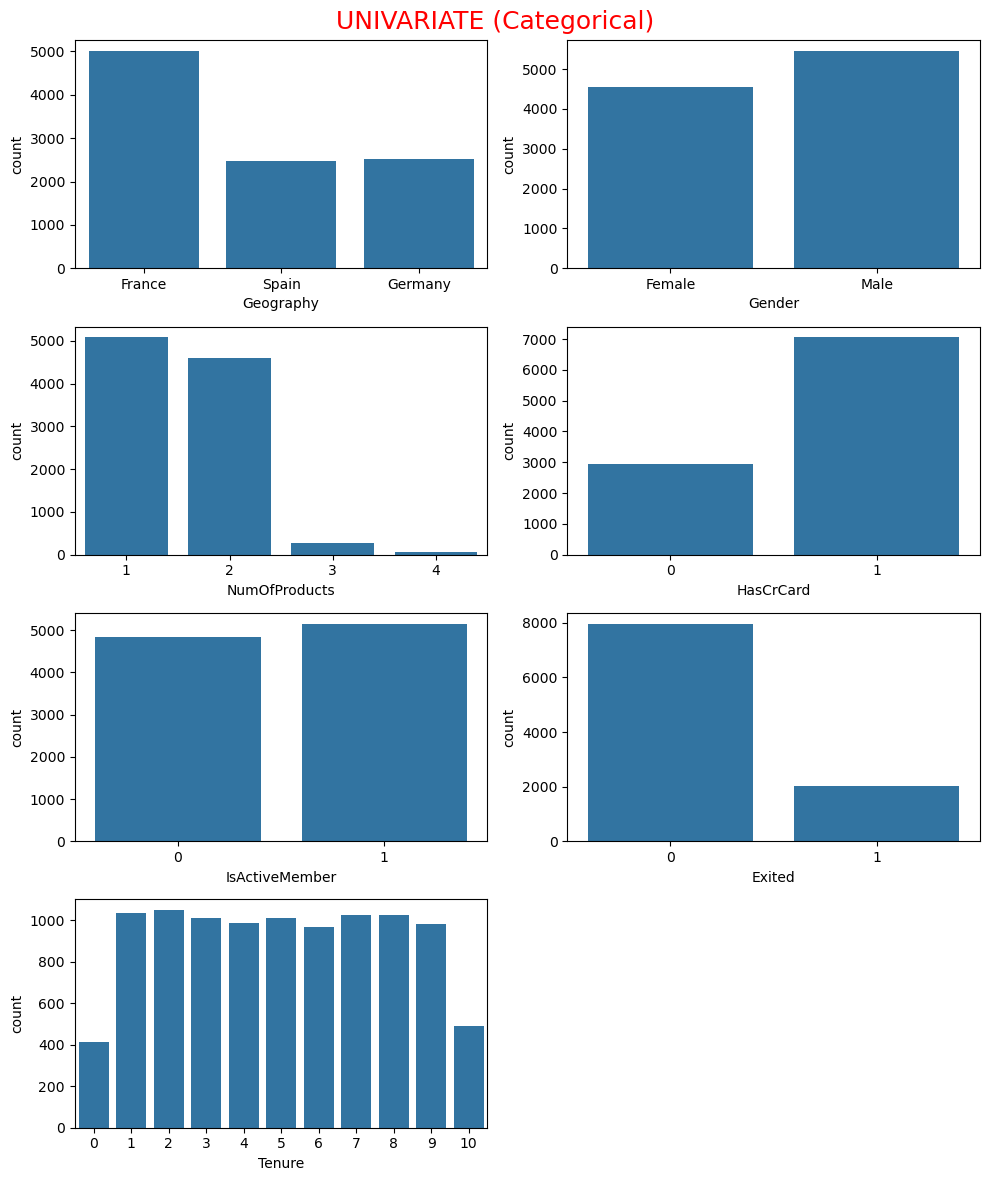

In [131]:
# Explore the Categorical columns

t=1
plt.figure(figsize=(10,12))
plt.suptitle('UNIVARIATE (Categorical)',color='red',size=18)
for i in cat_cols:
    plt.subplot(4,2,t)
    sns.countplot(data=df,x=i)
    t+=1
plt.tight_layout()
plt.show()

### Bivariate Analysis

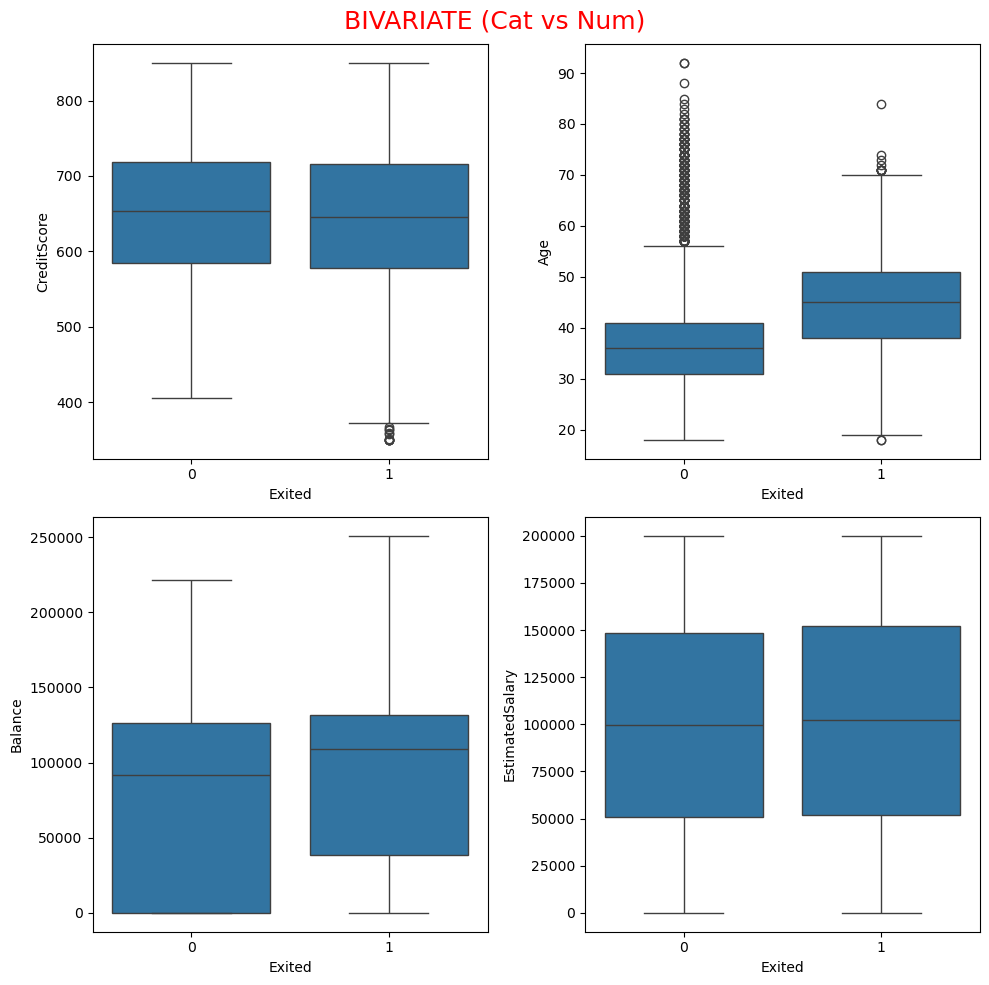

In [132]:
# Cat vs Num
t=1
plt.figure(figsize=(10,10))
plt.suptitle('BIVARIATE (Cat vs Num)',color='red',size=18)
for i in num_cols:
    plt.subplot(2,2,t)
    sns.boxplot(data=df,y=i,x='Exited')
    t+=1
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

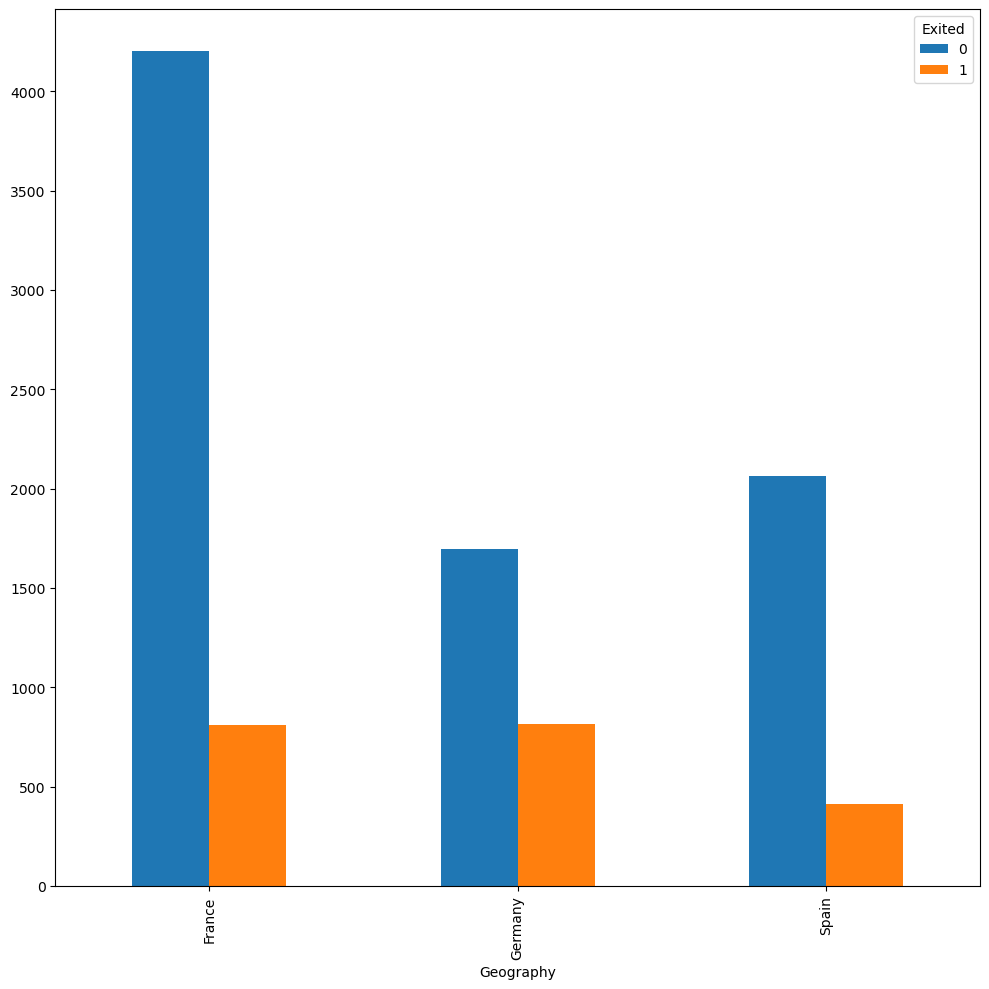

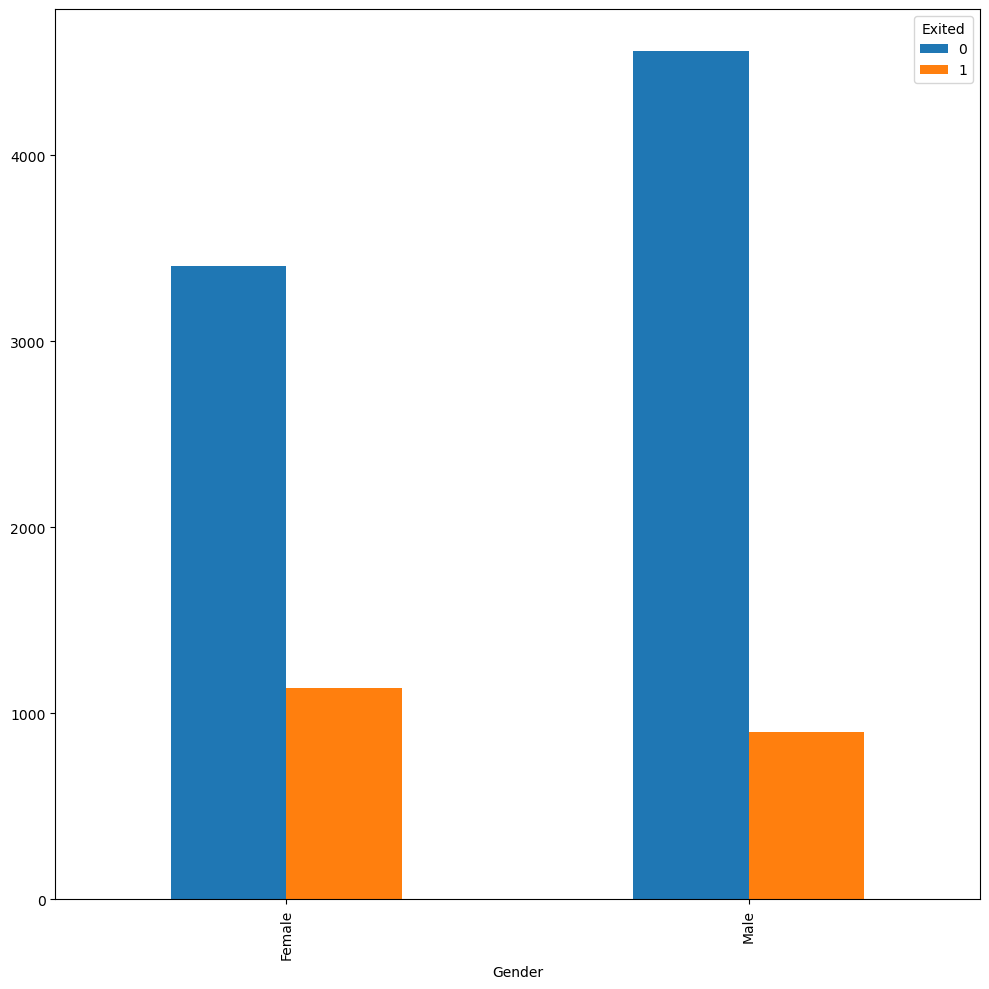

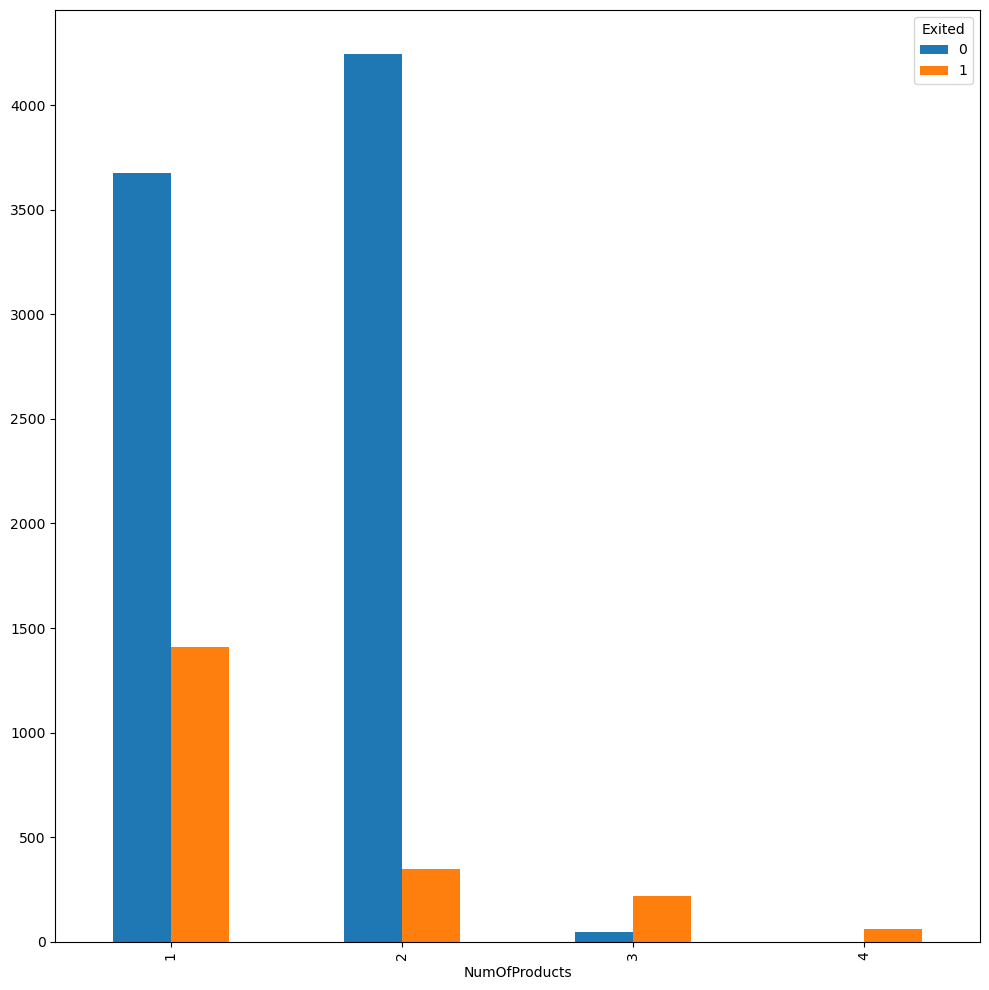

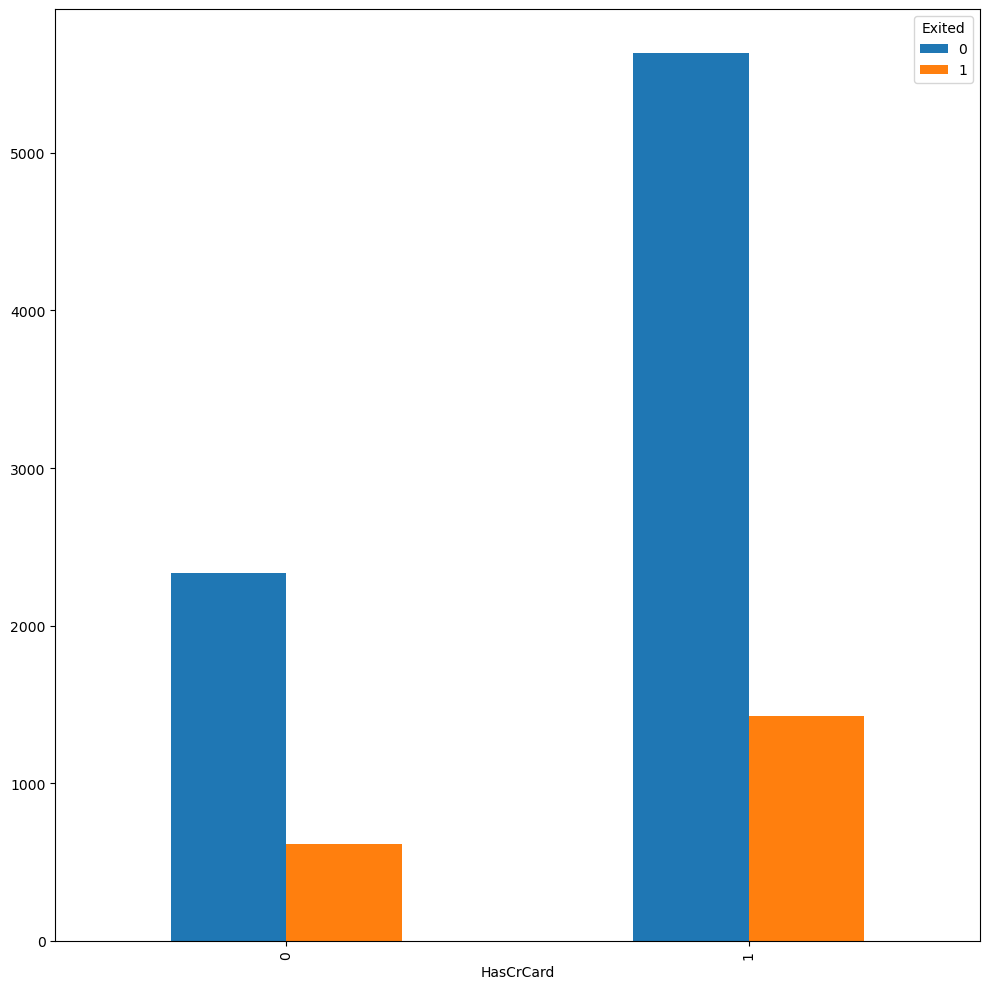

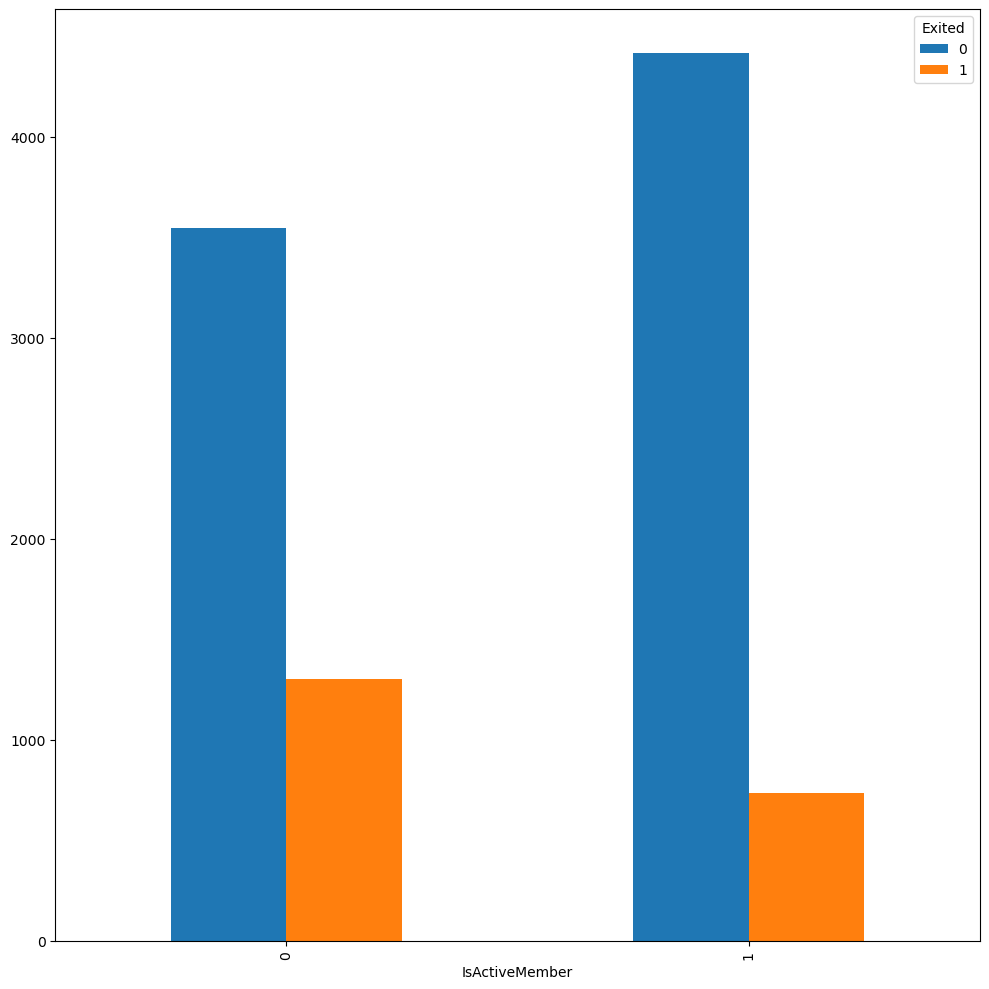

<Figure size 1000x1000 with 0 Axes>

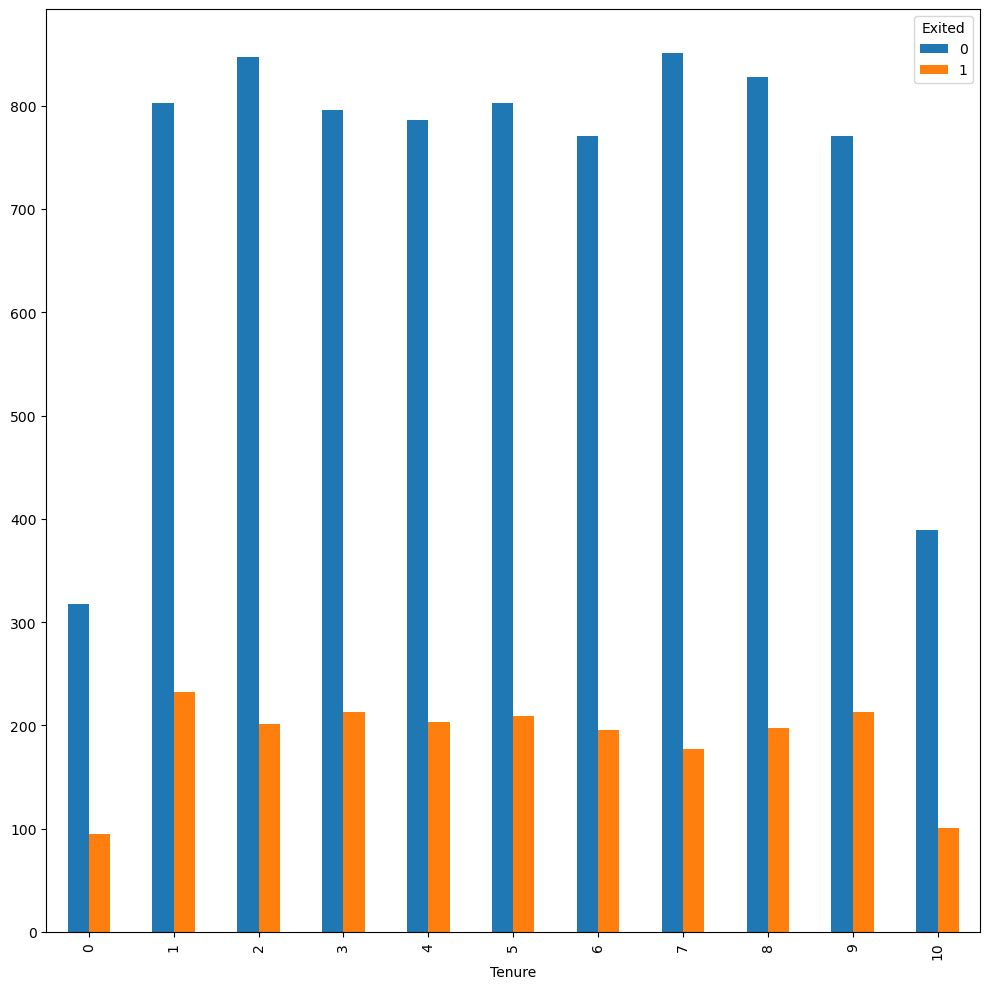

In [133]:
# cat vs cat

plt.figure(figsize=(10,10))
for i in cat_cols:
    if i != 'Exited':
        pd.crosstab(df[i],df['Exited']).plot(kind='bar')
    plt.tight_layout()
    plt.show()

### Multivariate Analysis

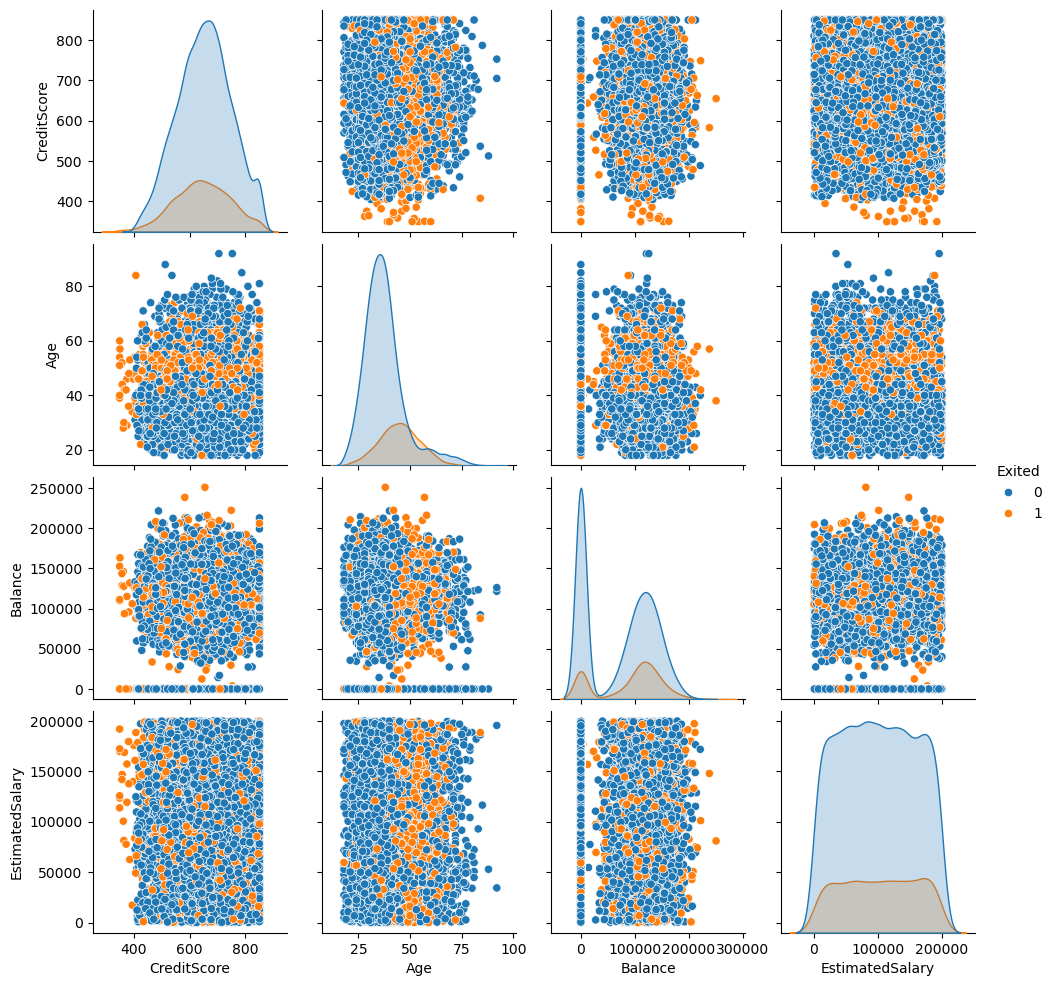

In [134]:
sns.pairplot(data=df,x_vars=num_cols,y_vars=num_cols,hue='Exited')

## Data Preprocessing 

In [135]:
df[num_cols].skew()

CreditScore       -0.071607
Age                1.011320
Balance           -0.141109
EstimatedSalary    0.002085
dtype: float64

In [136]:
# step2 : Calculate IQR

q2=df[num_cols].quantile(0.5)
q1=df[num_cols].quantile(0.25)
q3=df[num_cols].quantile(0.75)

iqr=q3-q1

uwl= q3+1.5*iqr
lwl= q1-1.5*iqr

In [137]:
outliers=df[((df[num_cols] < lwl) | (df[num_cols] > uwl)).any(axis=1)]
outliers

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
58,59,15623944,T'ien,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,86,15805254,Ndukaku,652,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,105,15804919,Dunbabin,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,159,15589975,Maclean,646,France,Female,73,6,97259.25,1,0,1,104719.66,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9753,9754,15705174,Chiedozie,656,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,9766,15777067,Thomas,445,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,9833,15814690,Chukwujekwu,595,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,9895,15704795,Vagin,521,France,Female,77,6,0.00,2,1,1,49054.10,0


In [138]:
len(outliers)/len(df)*100

3.74

In [139]:
#Drop outliers if it is <5% drop the outliers and reset the index

In [140]:
non_outliers=df[~((df[num_cols] < lwl) | (df[num_cols] > uwl)).any(axis=1)]
non_outliers

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [141]:
for i in cat_cols:
    print(df[i].value_counts())
    print('--'*40)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
--------------------------------------------------------------------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
--------------------------------------------------------------------------------
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
--------------------------------------------------------------------------------
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
--------------------------------------------------------------------------------
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
--------------------------------------------------------------------------------
Exited
0    7963
1    2037
Name: count, dtype: int64
--------------------------------------------------------------------------------
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490


In [142]:
non_outliers.drop(['RowNumber','Surname'],axis=1,inplace=True)
non_outliers.set_index('CustomerId',inplace=True)
non_outliers.head()

C:\Users\TECHVITY\AppData\Local\Temp\ipykernel_9916\410277939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers.drop(['RowNumber','Surname'],axis=1,inplace=True)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,
15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [143]:
df=pd.get_dummies(non_outliers,dtype=int,drop_first=True)
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
CustomerId,,,,,,,,,,,,
15634602,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
15619304,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
15701354,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15606229,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
15584532,709,36,7,0.00,1,0,1,42085.58,1,0,0,0


## Model Building and Evaluation

In [144]:
x=df.drop('Exited',axis=1)
y=df['Exited']

In [145]:
#Let's do train test split to validate the model

xtrain,xtest,ytrain,ytest=train_test_split(x,y,stratify=y,test_size=.2, random_state=100)

In [146]:
y.value_counts(normalize=True) #highly imbalanced

Exited
0    0.797528
1    0.202472
Name: proportion, dtype: float64

In [147]:
ytrain.value_counts(normalize=True)

Exited
0    0.797532
1    0.202468
Name: proportion, dtype: float64

In [148]:
ytest.value_counts(normalize=True)

Exited
0    0.797508
1    0.202492
Name: proportion, dtype: float64

In [149]:
# lets check the shape of the training and the test datset
print(xtrain.shape,ytrain.shape,xtest.shape,ytest.shape)

(7700, 11) (7700,) (1926, 11) (1926,)


## Baseline Model (Logistic Regression)

In [150]:
lr_model=LogisticRegression()

In [151]:
#train the model on the training data
lr_model.fit(xtrain,ytrain)

C:\Users\TECHVITY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [152]:
#let get the soft and hard prediction
ypred_s_lr=lr_model.predict_proba(xtest)[:,1]
ypred_h_lr=lr_model.predict(xtest)

In [153]:
#lets evaluate the model
print(confusion_matrix(ytest,ypred_h_lr))
print(classification_report(ytest,ypred_h_lr))

[[1484   52]
 [ 316   74]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1536
           1       0.59      0.19      0.29       390

    accuracy                           0.81      1926
   macro avg       0.71      0.58      0.59      1926
weighted avg       0.78      0.81      0.77      1926



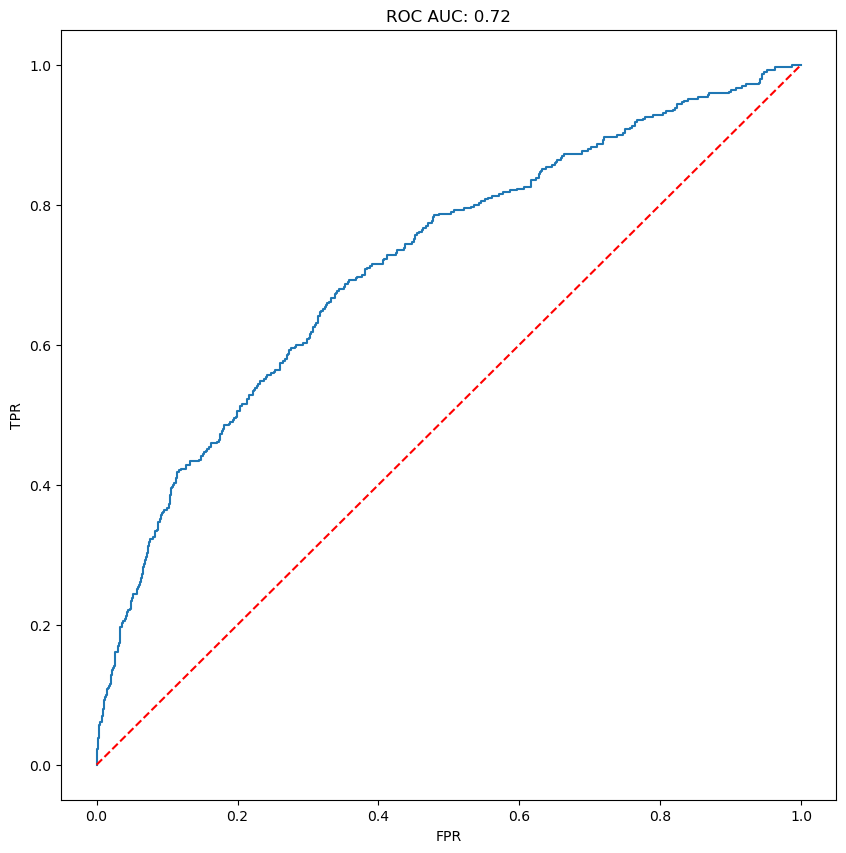

In [154]:
#Plot the roc curve
fpr_lr,tpr_lr,thres_lr = roc_curve(ytest,ypred_s_lr)

plt.plot(fpr_lr,tpr_lr)
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC: {round(roc_auc_score(ytest,ypred_s_lr),2)}')
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

## Inference:

1. In the baseline model we can observe that the recall of 1 is very low. Hence we can say that this model is not able to capture the customers who really have exited the bank.
2. Off course its not a good model. We need to improve the score and get the model which able to give better recall of 1.
3. One of the possibilities of getting a very low score in the minority class is the class imbalance in the target variable.
4. We can also try to lower the thershold by using Yoden's Index and see the best classification that this model can give. 

In [155]:
# In this ROC curve there should be one threshold where tpr is max and fpr min
# In order to get that therhold we use Yoden's Index
# YI = tpr*(1-fpr)
# Threshold at maximum YI will be the optimum threshold
pd.DataFrame({'FPR':fpr_lr,'TPR':tpr_lr,'Threshold':thres_lr,'YI':tpr_lr*(1-fpr_lr)})\
.sort_values(by='YI',ascending=False).head()

,FPR,TPR,Threshold,YI
328,0.340495,0.676923,0.190471,0.446434
326,0.339193,0.674359,0.190594,0.445621
330,0.344401,0.679487,0.188491,0.445471
327,0.340495,0.674359,0.190487,0.444743
334,0.352865,0.687179,0.185217,0.444698


In [156]:
ypred_h_lr_YI = (ypred_s_lr>0.190471).astype(int)

In [157]:
print(classification_report(ytest,ypred_h_lr_YI))

              precision    recall  f1-score   support

           0       0.89      0.66      0.76      1536
           1       0.34      0.68      0.45       390

    accuracy                           0.66      1926
   macro avg       0.61      0.67      0.60      1926
weighted avg       0.78      0.66      0.69      1926



In [158]:
# Now lest check the reliability of the scores given by the model
# Cohen-Kappa Score
print('Cohen Kappa:',cohen_kappa_score(ytest,ypred_h_lr))
print('Cohen Kappa (Adjusting Threshold using YI):',cohen_kappa_score(ytest,ypred_h_lr_YI))

Cohen Kappa: 0.2085544299726645
Cohen Kappa (Adjusting Threshold using YI): 0.24383409495947472


**Inference**
* Cohen kappa score for baseline model showed a very poor agreement between actual and predicted. Hence this model is not reliable.
* Although the cohen kappa score increased when the thershold was adjusted, but still its not reliable.

## Handling Class Imbalance

* Resampling the data
    * Oversampling
    * Undersampling
    * SMOTE (Synthetic Minority Oversampling technique)

* Class weights

In [159]:
y.value_counts()

Exited
0    7677
1    1949
Name: count, dtype: int64

In [160]:
sampler = SMOTE(sampling_strategy=0.7)

# sampling_strategy = minority class / majority class 

# SMOTE
# Type of oversampling ie it will add the new data
# But this technique fabricates a new data instead of adding duplicated rows

In [161]:
x_train_b, y_train_b = sampler.fit_resample(xtrain,ytrain)

## Fit the Baseline Model with Resampled data

In [162]:
model_lr_rs = LogisticRegression()

In [163]:
model_lr_rs.fit(x_train_b,y_train_b)

C:\Users\TECHVITY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [164]:
ypred_s_lr_rs = model_lr_rs.predict_proba(xtest)[:,1]
ypred_h_lr_rs = (ypred_s_lr_rs>0.5).astype(int)

In [165]:
print(classification_report(ytest,ypred_h_lr_rs))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1536
           1       0.40      0.53      0.46       390

    accuracy                           0.74      1926
   macro avg       0.63      0.66      0.64      1926
weighted avg       0.77      0.74      0.76      1926



In [166]:
fpr_lr_rs,tpr_lr_rs,thres_lr_rs = roc_curve(ytest,ypred_s_lr_rs)

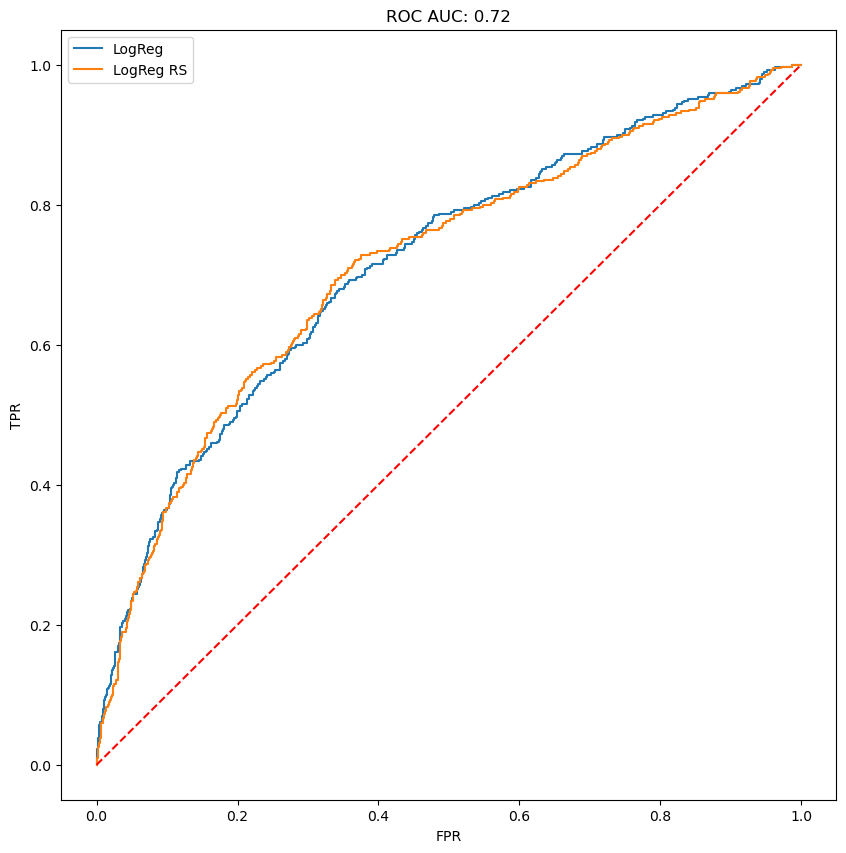

In [167]:
plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg RS')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC: {round(roc_auc_score(ytest,ypred_s_lr_rs),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

In [168]:
print('cohen kappa:',cohen_kappa_score(ytest,ypred_h_lr_rs))

cohen kappa: 0.2921070877412718


## Fitting A Baseline Model Using Class Weights

In [169]:
model_lr_CW = LogisticRegression(class_weight='balanced')

In [170]:
model_lr_CW.fit(xtrain,ytrain)

C:\Users\TECHVITY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [171]:
ypred_s_lr_CW = model_lr_CW.predict_proba(xtest)[:,1]
ypred_h_lr_CW = (ypred_s_lr_CW>0.5).astype(int)

In [172]:
print(classification_report(ytest,ypred_h_lr_CW))

              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1536
           1       0.35      0.69      0.47       390

    accuracy                           0.68      1926
   macro avg       0.62      0.68      0.62      1926
weighted avg       0.79      0.68      0.71      1926



In [173]:
print('ROC AUC:',roc_auc_score(ytest,ypred_s_lr_CW))

ROC AUC: 0.7262236244658119


In [174]:
print('Cohen Kappa:',cohen_kappa_score(ytest,ypred_h_lr_CW))

Cohen Kappa: 0.26931520169726264


## KNN

In [175]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
CustomerId,,,,,,,,,,,,
15634602,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
15619304,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
15701354,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [176]:
# data must be scaled

cols_scaled = ['CreditScore','Age','Balance','EstimatedSalary']
scaler = RobustScaler()
x_train_s = x_train_b.copy()
x_test_s = xtest.copy()

x_train_s[cols_scaled] = scaler.fit_transform(x_train_s[cols_scaled])
x_test_s[cols_scaled] = scaler.transform(x_test_s[cols_scaled])

In [177]:
x_test_s.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
CustomerId,,,,,,,,,,,
15707637,0.898438,1.416667,1,-0.792852,1,1,0,-0.893790,0,0,0
15672144,0.132812,-0.083333,6,0.329647,1,1,1,-0.275201,0,0,0
15569678,-0.695312,-0.583333,6,0.503677,1,1,0,0.391814,1,0,1
15803365,0.023438,1.333333,2,-0.246775,1,0,1,-0.393507,0,1,1
15717700,0.257812,-0.416667,9,0.097872,2,0,1,-0.770444,0,1,1


In [178]:
param_grid = {'n_neighbors':[5,7,9,11]}
gscv = GridSearchCV(estimator=KNeighborsClassifier(),
                   param_grid=param_grid,
                   scoring='roc_auc',
                   cv=5,verbose=0)
gscv.fit(x_train_s,y_train_b)


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [5, 7, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [179]:
gscv.best_params_

{'n_neighbors': 11}

In [180]:
gscv.best_score_

np.float64(0.8732504943097951)

In [181]:
model_knn = KNeighborsClassifier(**gscv.best_params_)

In [182]:
model_knn.fit(x_train_s,y_train_b)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [183]:
ypred_s_knn = model_knn.predict_proba(x_test_s)[:,1]

In [184]:
ypred_h_knn = (ypred_s_knn>0.5).astype(int)

In [185]:
print(classification_report(ytest,ypred_h_knn))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1536
           1       0.49      0.54      0.51       390

    accuracy                           0.79      1926
   macro avg       0.68      0.70      0.69      1926
weighted avg       0.80      0.79      0.80      1926



In [186]:
print('ROC-AUC',roc_auc_score(ytest,ypred_s_knn))

ROC-AUC 0.802662593482906


In [187]:
print('Cohen kappa:',cohen_kappa_score(ytest,ypred_h_knn))

Cohen kappa: 0.38066756704611227


In [188]:
fpr_knn,tpr_knn,thres_knn = roc_curve(ytest,ypred_s_knn)

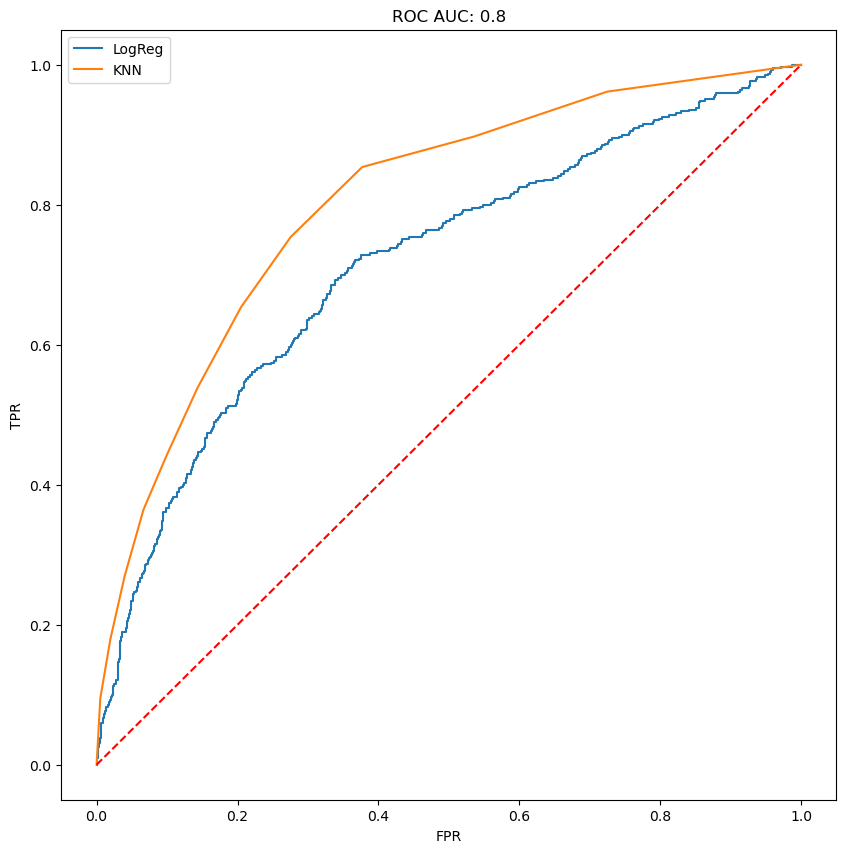

In [189]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_knn,tpr_knn,label='KNN')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC: {round(roc_auc_score(ytest,ypred_s_knn),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

## Decision Tree

In [190]:
model_dt=DecisionTreeClassifier(criterion='entropy',class_weight='balanced',max_depth=6)

# By deafult a full grown tree is always an overfitted model
# In order reduce this overfitting we need to restrict the growth of the tree
# We use pruning. there are different hyperparameters to prune the tree
# max_depth
# min_sample_leaf
# min_sample_split
# max_leaf_nodes

In [191]:
model_dt.fit(xtrain,ytrain)

,criterion,'entropy'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [192]:
ypred_s_dt = model_dt.predict_proba(xtest)[:,1]
ypred_h_dt = (ypred_s_dt>0.5).astype(int)

In [193]:
print(classification_report(ytest,ypred_h_dt))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      1536
           1       0.48      0.77      0.59       390

    accuracy                           0.78      1926
   macro avg       0.70      0.78      0.72      1926
weighted avg       0.84      0.78      0.80      1926



In [194]:
xtrain

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
CustomerId,,,,,,,,,,,
15586425,579,28,4,0.00,2,1,1,176925.69,0,0,1
15577359,767,47,5,0.00,1,1,0,121964.46,0,1,1
15637354,623,24,7,148167.83,2,1,1,109470.34,0,0,0
15802351,755,33,6,90560.30,2,1,1,42607.69,1,0,0
15636999,414,38,8,0.00,1,0,1,77661.12,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
15648064,649,33,2,0.00,2,1,0,2010.98,0,0,1
15794870,744,38,6,73023.17,2,1,0,78770.86,1,0,1
15588614,753,57,7,0.00,1,1,0,159475.08,0,0,1


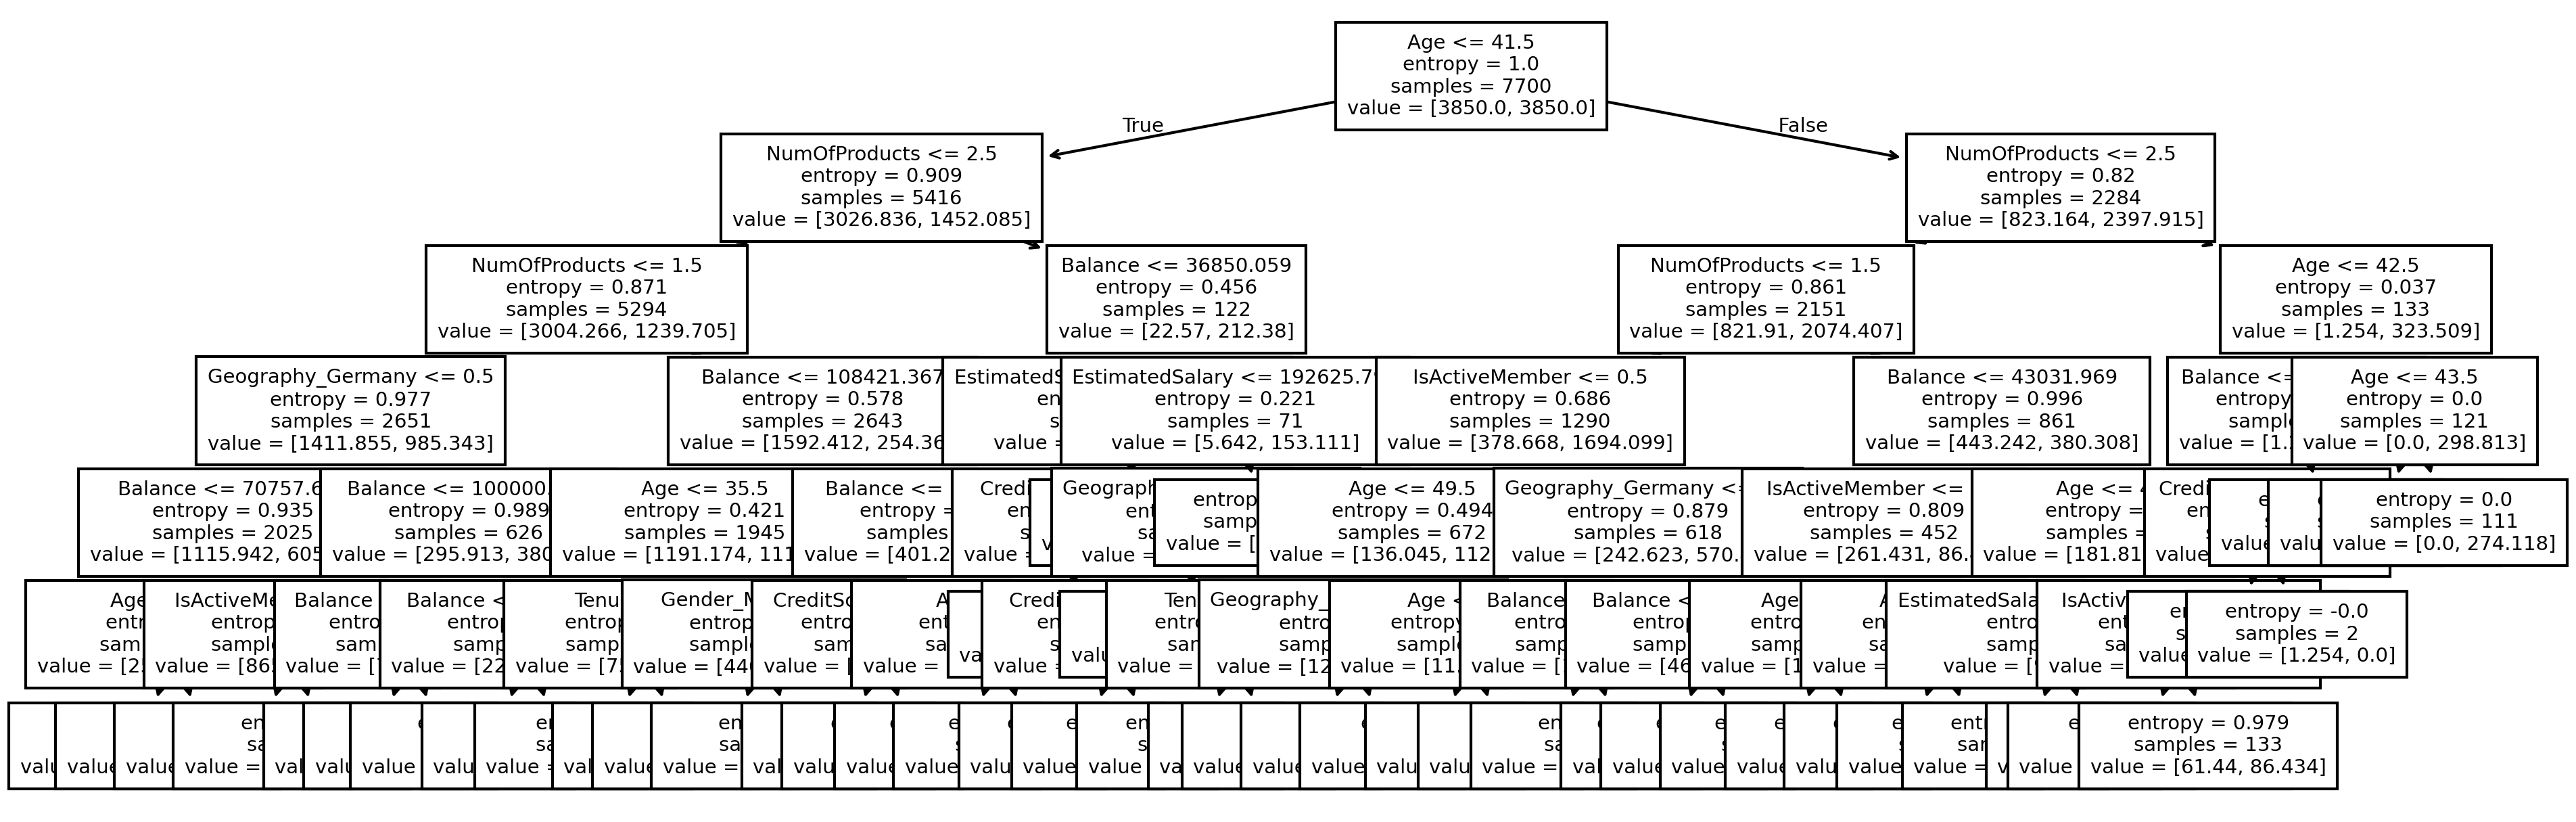

In [195]:
plt.figure(figsize=(15,5),dpi=300)
plot_tree(model_dt,feature_names=xtrain.columns,fontsize=7)
plt.show()

In [196]:
fpr_dt,tpr_dt,thres_dt = roc_curve(ytest,ypred_s_dt)

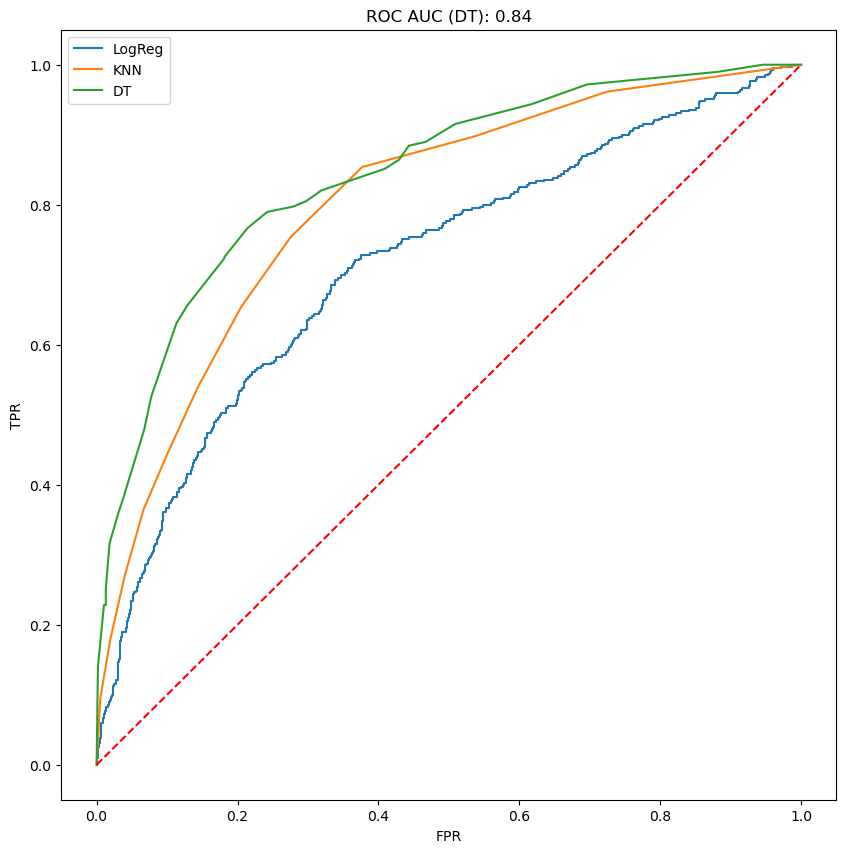

In [197]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_knn,tpr_knn,label='KNN')
plt.plot(fpr_dt,tpr_dt,label='DT')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC (DT): {round(roc_auc_score(ytest,ypred_s_dt),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

In [198]:
print('Reliability:',cohen_kappa_score(ytest,ypred_h_dt))

Reliability: 0.45002406807594086


## Ensemble Learning

### Bagging

In [199]:
model_bagg = BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=5),
                              n_estimators=50,oob_score=True)

In [200]:
model_bagg.fit(x_train_b,y_train_b)

,estimator,KNeighborsClassifier()
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [201]:
ypred_s_bagg = model_bagg.predict_proba(xtest)[:,1]
ypred_h_bagg = (ypred_s_bagg>0.5).astype(int)

In [202]:
print(classification_report(ytest,ypred_h_bagg))

              precision    recall  f1-score   support

           0       0.80      0.72      0.76      1536
           1       0.21      0.30      0.25       390

    accuracy                           0.63      1926
   macro avg       0.51      0.51      0.50      1926
weighted avg       0.68      0.63      0.65      1926



## Random Forest

In [203]:
model_rf = RandomForestClassifier(n_estimators=50,
                                 max_depth=5,max_features=None,
                                 class_weight='balanced')

In [204]:
model_rf.fit(xtrain,ytrain)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [205]:
ypred_s_rf = model_rf.predict_proba(xtest)[:,1]
ypred_h_rf = (ypred_s_rf>0.5).astype(int)

In [206]:
print(classification_report(ytest,ypred_h_rf))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1536
           1       0.51      0.71      0.59       390

    accuracy                           0.80      1926
   macro avg       0.71      0.77      0.73      1926
weighted avg       0.84      0.80      0.81      1926



In [207]:
roc_auc_score(ytest,ypred_s_rf)

0.8456029647435899

In [208]:
fpr_rf,tpr_rf,thres_rf = roc_curve(ytest,ypred_s_rf)

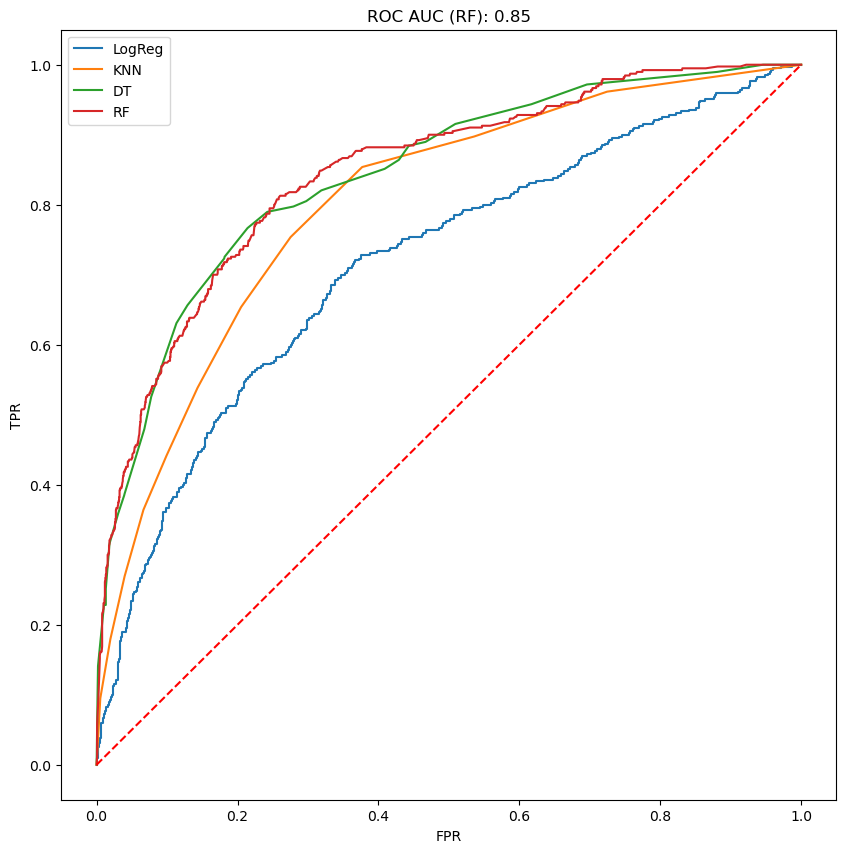

In [209]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_knn,tpr_knn,label='KNN')
plt.plot(fpr_dt,tpr_dt,label='DT')
plt.plot(fpr_rf,tpr_rf,label='RF')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC (RF): {round(roc_auc_score(ytest,ypred_s_rf),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

In [210]:
print('Reliability:',cohen_kappa_score(ytest,ypred_h_rf))

Reliability: 0.4685849428458809


In [211]:
pd.DataFrame({'FI':model_rf.feature_importances_},index=xtrain.columns)\
.sort_values(by='FI',ascending=False)

,FI
Age,0.490587
NumOfProducts,0.323730
Balance,0.070159
IsActiveMember,0.051993
Geography_Germany,0.040504
EstimatedSalary,0.008611
Gender_Male,0.006791
CreditScore,0.003458
Tenure,0.002556
Geography_Spain,0.001006


In [212]:
estimator = RandomForestClassifier(n_estimators=50,
            max_depth=5,max_features=None,class_weight='balanced')

In [213]:
cv_scores = cross_val_score(estimator=estimator, cv=KFold(n_splits=5,shuffle=True),
                            scoring='roc_auc',verbose=0,X=xtrain,y=ytrain)

## AdaBoost

In [214]:
model_ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=150)

In [215]:
model_ada.fit(x_train_b,y_train_b)

,estimator,DecisionTreeC...r(max_depth=3)
,n_estimators,150
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [216]:
ypred_s_ada = model_ada.predict_proba(xtest)[:,1]
ypred_h_ada = (ypred_s_ada>0.5).astype(int)

In [217]:
print(classification_report(ytest,ypred_h_ada))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1536
           1       0.54      0.59      0.56       390

    accuracy                           0.81      1926
   macro avg       0.71      0.73      0.72      1926
weighted avg       0.82      0.81      0.82      1926



In [218]:
fpr_ada,tpr_ada,thres_ada = roc_curve(ytest,ypred_s_ada)

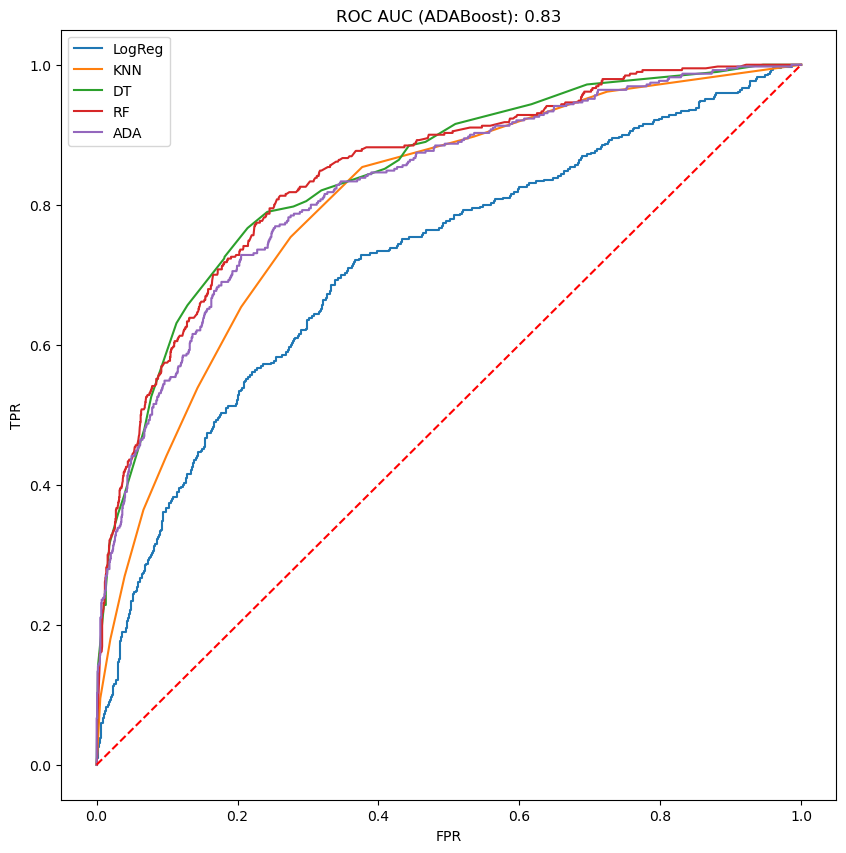

In [219]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_knn,tpr_knn,label='KNN')
plt.plot(fpr_dt,tpr_dt,label='DT')
plt.plot(fpr_rf,tpr_rf,label='RF')
plt.plot(fpr_ada,tpr_ada,label='ADA')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC (ADABoost): {round(roc_auc_score(ytest,ypred_s_ada),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

## Gradient Boosting

In [220]:
model_gbm = GradientBoostingClassifier(n_estimators=150,learning_rate=0.1,max_depth=5)

In [221]:
model_gbm.fit(x_train_b,y_train_b)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [222]:
ypred_s_gbm = model_gbm.predict_proba(xtest)[:,1]
ypred_h_gbm = (ypred_s_gbm>0.5).astype(int)

In [223]:
print(classification_report(ytest,ypred_h_gbm))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1536
           1       0.56      0.56      0.56       390

    accuracy                           0.82      1926
   macro avg       0.72      0.72      0.72      1926
weighted avg       0.82      0.82      0.82      1926



In [224]:
print('Reliability:',cohen_kappa_score(ytest,ypred_h_gbm))

Reliability: 0.4491296886491787


In [225]:
print('ROC-AUC',roc_auc_score(ytest,ypred_s_gbm))

ROC-AUC 0.8286875667735043


In [226]:
fpr_gbm, tpr_gbm, thres_gbm = roc_curve(ytest,ypred_s_gbm)

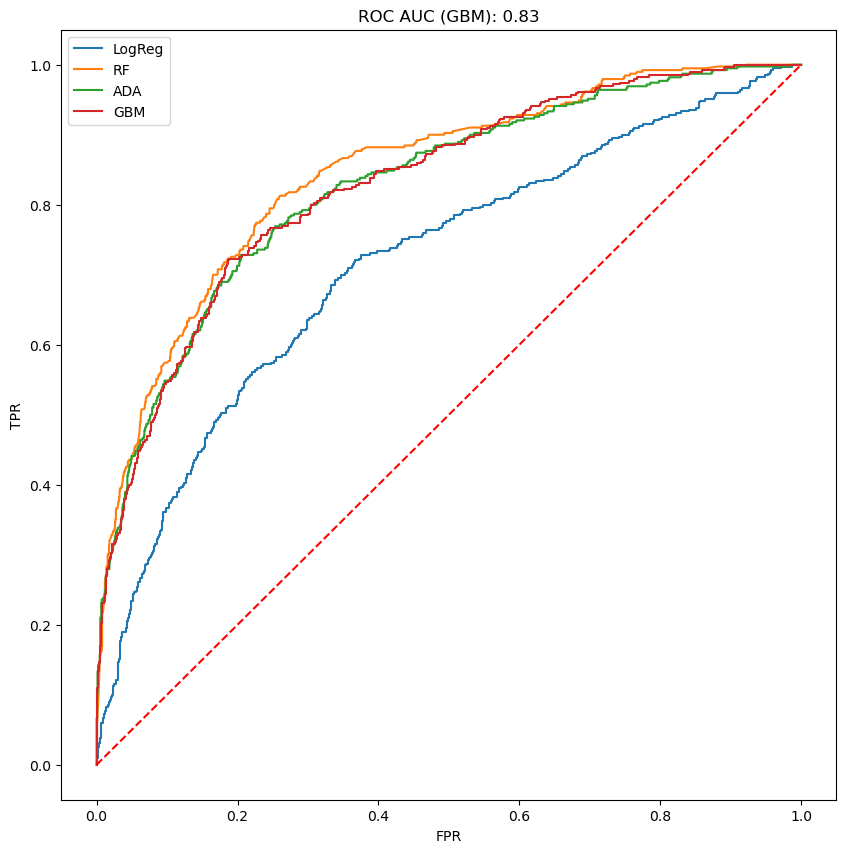

In [227]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_rf,tpr_rf,label='RF')
plt.plot(fpr_ada,tpr_ada,label='ADA')
plt.plot(fpr_gbm,tpr_gbm,label='GBM')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC (GBM): {round(roc_auc_score(ytest,ypred_s_gbm),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

## XGBoost

In [228]:
model_xgb = XGBClassifier(n_estimators=200,min_child_weight=1,learning_rate=0.01,
                         reg_lambda=2)

In [229]:
model_xgb.fit(x_train_b,y_train_b)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [230]:
ypred_s_xgb = model_xgb.predict_proba(xtest)[:,1]
ypred_h_xgb = (ypred_s_xgb>0.5).astype(int)

In [231]:
print(classification_report(ytest,ypred_h_xgb))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1536
           1       0.55      0.57      0.56       390

    accuracy                           0.82      1926
   macro avg       0.72      0.72      0.72      1926
weighted avg       0.82      0.82      0.82      1926



In [232]:
print('Reliability:',cohen_kappa_score(ytest,ypred_h_xgb))

Reliability: 0.44373477511734294


In [233]:
fpr_xgb,tpr_xgb, thres_xgb = roc_curve(ytest,ypred_s_xgb)

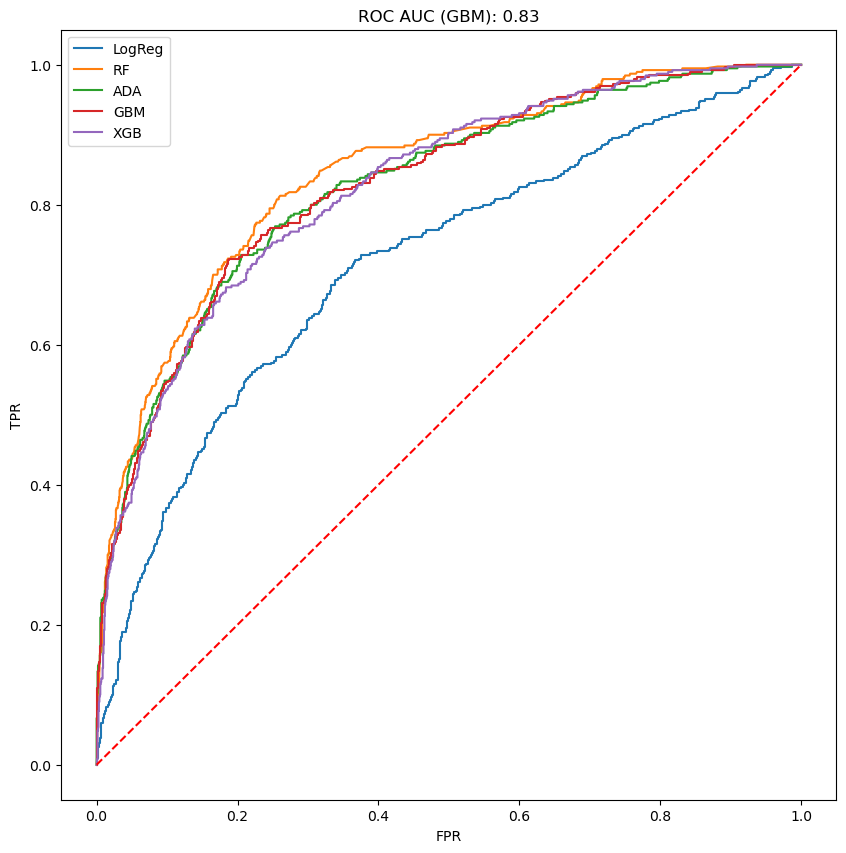

In [234]:
plt.plot(fpr_lr_rs,tpr_lr_rs,label='LogReg')
plt.plot(fpr_rf,tpr_rf,label='RF')
plt.plot(fpr_ada,tpr_ada,label='ADA')
plt.plot(fpr_gbm,tpr_gbm,label='GBM')
plt.plot(fpr_xgb,tpr_xgb,label='XGB')
plt.plot([0,1],[0,1],ls='--',color='red')
plt.title(f'ROC AUC (GBM): {round(roc_auc_score(ytest,ypred_s_xgb),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

This was a customer churn prediction project for a bank. Since the business goal was to identify customers likely to leave, I prioritized Recall for the churn class rather than accuracy alone. After comparing multiple models, I selected an **AdaBoost classifier with a Decision Tree base estimator (max_depth=3, n_estimators=150)**. The model achieved approximately **81% accuracy and 59% recall for churners**, meaning it correctly identified 59% of customers who were likely to leave. This allows the bank to take proactive retention actions and reduce customer attrition